# Antennas & Electromagnetic Propagation

An antenna converts electrical energy into radiating electromagnetic waves — and vice versa.  
Every antenna has a **radiation pattern**: the angular distribution of radiated power in 3D space.

## Core quantities

| Symbol | Name | Meaning |
|--------|------|---------|
| $D(\theta,\phi)$ | Directivity | Power density vs. isotropic radiator |
| $G$ | Gain | Directivity × radiation efficiency |
| $\lambda$ | Wavelength | $c/f$ |
| $k$ | Wave number | $2\pi/\lambda$ |

## Half-wave dipole
The **half-wave dipole** ($L = \lambda/2$) is the reference antenna.  
Its element factor (normalised E-field in elevation) is:
$$F(\theta) = \frac{\cos\!\left(\frac{\pi}{2}\cos\theta\right)}{\sin\theta}$$
where $\theta$ is measured from the dipole axis.  
Peak directivity $D \approx 1.64$ (2.15 dBi).  
Short dipole ($L\ll\lambda$): $F(\theta)=\sin\theta$.

In [5]:
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from ipywidgets import (
    FloatSlider, IntSlider, Dropdown,
    HBox, VBox, Output, Label
)
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.signal import argrelmax

theta = np.linspace(0, 2 * np.pi, 3600)   # full azimuth for polar plots
th_deg = np.linspace(-90, 90, 3600)        # elevation cut
th_rad = np.radians(th_deg)

# ---------- shared helpers ----------
def dipole_pattern(theta_rad, L_over_lambda):
    kL2 = np.pi * L_over_lambda
    s = np.sin(theta_rad)
    c = np.cos(theta_rad)
    with np.errstate(divide='ignore', invalid='ignore'):
        num = np.cos(kL2 * c) - np.cos(kL2)
        F = np.where(np.abs(s) < 1e-9, 0.0, num / s)
    F = np.abs(F)
    return F / (F.max() + 1e-30)

def sinc_safe(x):
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(np.abs(x) < 1e-10, 1.0, np.sin(x) / x)

def pat_metrics(pat, angles_deg=th_deg, angles_rad=th_rad):
    dB   = 20 * np.log10(pat + 1e-12)
    hp   = np.where(dB >= -3)[0]
    hpbw = angles_deg[hp[-1]] - angles_deg[hp[0]] if len(hp) else np.nan
    pks  = argrelmax(pat, order=20)[0]
    main = pks[np.argmax(pat[pks])] if len(pks) else None
    sds  = [p for p in pks if p != main]
    sll  = 20 * np.log10(max(pat[sds])) if sds else -60.0
    Pr   = np.trapezoid(pat**2 * np.abs(np.cos(angles_rad)), angles_rad)
    D    = 10 * np.log10(2 * pat.max()**2 / (Pr + 1e-30))
    return hpbw, sll, D

# ---------- Dipole ----------
w_L = FloatSlider(value=0.5, min=0.1, max=2.0, step=0.05,
                  description='L/λ', continuous_update=False,
                  style={'description_width': '40px'})
out_dip = Output()

def draw_dipole(change=None):
    F = dipole_pattern(theta, w_L.value)
    hpbw, sll, D = pat_metrics(dipole_pattern(th_rad + np.pi/2, w_L.value))
    with out_dip:
        clear_output(wait=True)
        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(5, 5))
        ax.plot(theta, F, lw=2, color='steelblue')
        ax.set_ylim(0, 1.05)
        ax.set_title(f'Dipole L={w_L.value:.2f}λ   HPBW={hpbw:.1f}°  D={D:.1f} dBi', pad=14)
        plt.tight_layout(); plt.show()

w_L.observe(draw_dipole, names='value')
draw_dipole()
display(VBox([w_L, out_dip]))

## Phased Array — Array Factor & Beam Steering

When $N$ identical elements are arranged along an axis, the total radiation pattern is:
$$E_{\text{tot}}(\theta) = F_{\text{element}}(\theta)\cdot AF(\theta)$$
The **Array Factor** for a uniform linear array with spacing $d$ and progressive phase $\delta$:
$$|AF| = \frac{1}{N}\left|\frac{\sin(N\psi/2)}{\sin(\psi/2)}\right|, \quad \psi = kd\cos\theta + \delta$$

**Beam steering**: $\delta = -kd\cos\theta_0$ points the main beam at $\theta_0$.  
**Grating lobes** appear when $d > \lambda/2$ — identical copies of the main beam at other angles.

In [ ]:
w_N   = IntSlider(value=8,   min=2,   max=32,  step=1,    description='Elements N',   continuous_update=False, style={'description_width': '90px'})
w_d   = FloatSlider(value=0.5, min=0.1, max=1.5, step=0.05, description='Spacing d/λ', continuous_update=False, style={'description_width': '90px'})
w_ang = FloatSlider(value=0.0, min=-90, max=90,  step=1.0,  description='Steer θ₀ (°)', continuous_update=False, style={'description_width': '90px'})
w_el  = FloatSlider(value=0.5, min=0.1, max=2.0, step=0.05, description='Elem L/λ',    continuous_update=False, style={'description_width': '90px'})
out_arr = Output()

def draw_array(change=None):
    N   = w_N.value;  d = w_d.value
    th0 = np.radians(w_ang.value);  L = w_el.value
    k = 2 * np.pi
    delta = -k * d * np.cos(th0)
    psi   = k * d * np.cos(theta) + delta
    with np.errstate(divide='ignore', invalid='ignore'):
        AF = np.where(np.abs(np.sin(psi/2)) < 1e-12, 1.0,
                      np.abs(np.sin(N*psi/2) / (N*np.sin(psi/2))))
    EF  = dipole_pattern(theta, L)
    TOT = AF * EF;  TOT /= TOT.max() + 1e-30

    xs     = np.arange(N) * d
    delays = np.arange(N) * delta / (2*np.pi)

    with out_arr:
        clear_output(wait=True)
        fig = plt.figure(figsize=(13, 9))
        ax1 = fig.add_subplot(221, projection='polar')
        ax2 = fig.add_subplot(222, projection='polar')
        ax3 = fig.add_subplot(212)

        ax1.plot(theta, AF,  lw=2, color='tomato',    label='AF')
        ax1.plot(theta, EF,  lw=2, color='steelblue', label='Element')
        ax1.set_ylim(0, 1.05);  ax1.legend(loc='upper right', fontsize=8)
        ax1.set_title('AF vs Element factor', pad=10)

        ax2.plot(theta, TOT, lw=2, color='gold')
        ax2.set_ylim(0, 1.05)
        ax2.set_title('Total = AF × Element', pad=10)

        ax3.stem(xs, delays, linefmt='steelblue', markerfmt='o', basefmt='gray')
        ax3.axhline(0, color='gray', lw=0.7)
        ax3.set_title(f'Array layout  N={N}  d={d:.2f}λ  θ₀={w_ang.value:.0f}°  δ={np.degrees(delta):.1f}°/element')
        ax3.set_xlabel('Element position [λ]');  ax3.set_ylabel('Phase delay [λ]')
        ax3.grid(alpha=0.3)

        plt.tight_layout();  plt.show()

for w in [w_N, w_d, w_ang, w_el]:
    w.observe(draw_array, names='value')
draw_array()
display(VBox([HBox([w_N, w_d]), HBox([w_ang, w_el]), out_arr]))

## 2-D Planar Array (uv Heat-Map)

For a planar $N_x \times N_y$ array the pattern separates:
$$AF_{2D}(u,v) = AF_x(u) \cdot AF_y(v), \quad u=\sin\theta\cos\phi,\; v=\sin\theta\sin\phi$$

The visible half-space is the unit disk $u^2+v^2\le1$.  
The cyan cross marks the steered direction $(u_0, v_0)$.

In [ ]:
w_Nx = IntSlider(value=8,   min=2, max=20, step=1,    description='Nx',   continuous_update=False, style={'description_width':'40px'})
w_Ny = IntSlider(value=8,   min=2, max=20, step=1,    description='Ny',   continuous_update=False, style={'description_width':'40px'})
w_dx = FloatSlider(value=0.5, min=0.25, max=1.0, step=0.05, description='dx/λ', continuous_update=False, style={'description_width':'40px'})
w_dy = FloatSlider(value=0.5, min=0.25, max=1.0, step=0.05, description='dy/λ', continuous_update=False, style={'description_width':'40px'})
w_u0 = FloatSlider(value=0.0, min=-0.9, max=0.9, step=0.05, description='u₀',  continuous_update=False, style={'description_width':'40px'})
w_v0 = FloatSlider(value=0.0, min=-0.9, max=0.9, step=0.05, description='v₀',  continuous_update=False, style={'description_width':'40px'})
out_2d = Output()

N_UV = 250
u1d  = np.linspace(-1, 1, N_UV)
uu, vv = np.meshgrid(u1d, u1d)
mask = uu**2 + vv**2 <= 1.0

def af1d_grid(u_grid, N, d, u0):
    psi = 2*np.pi * d * (u_grid - u0)
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(np.abs(np.sin(psi/2)) < 1e-12, 1.0,
                        np.abs(np.sin(N*psi/2) / (N*np.sin(psi/2))))

def draw_2d(change=None):
    pat = np.where(mask, af1d_grid(uu, w_Nx.value, w_dx.value, w_u0.value) *
                         af1d_grid(vv, w_Ny.value, w_dy.value, w_v0.value), np.nan)
    with out_2d:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(pat, origin='lower', extent=[-1,1,-1,1],
                       cmap='inferno', vmin=0, vmax=1, aspect='equal')
        ax.scatter([w_u0.value],[w_v0.value], marker='+', s=250, color='cyan', zorder=5)
        ax.add_patch(plt.Circle((0,0), 1, color='white', fill=False, lw=1))
        ax.set_xlabel('u = sinθ cosφ');  ax.set_ylabel('v = sinθ sinφ')
        ax.set_title(f'Planar array {w_Nx.value}×{w_Ny.value}  steer ({w_u0.value:.2f},{w_v0.value:.2f})')
        plt.colorbar(im, ax=ax, fraction=0.046)
        plt.tight_layout();  plt.show()

for w in [w_Nx, w_Ny, w_dx, w_dy, w_u0, w_v0]:
    w.observe(draw_2d, names='value')
draw_2d()
display(VBox([HBox([w_Nx, w_Ny, w_dx, w_dy]), HBox([w_u0, w_v0]), out_2d]))

## Vivaldi Antenna

The **Vivaldi** (tapered slot) is an ultra-wideband **end-fire** radiator on a PCB.  
Energy travels along an exponentially flared slot:
$$y(x) = C_1 e^{R_x x} + C_2$$
Large $R_x$ → rapid opening → wider beam. Small $R_x$ → narrower beam, longer antenna.

Far-field (cosine-tapered aperture model, main beam at $\theta=0°$):
$$E(\theta) = \cos^n\!\theta\cdot\operatorname{sinc}\!\left(\frac{\pi a}{\lambda}\sin\theta\right)$$
Aperture $a$ sets beamwidth; taper order $n$ controls side-lobe roll-off.

In [ ]:
w_va = FloatSlider(value=1.0, min=0.2, max=4.0, step=0.1,   description='Aperture a/λ', continuous_update=False, style={'description_width':'100px'})
w_vn = FloatSlider(value=2.0, min=0.5, max=8.0, step=0.5,   description='Taper n',       continuous_update=False, style={'description_width':'100px'})
w_vR = FloatSlider(value=0.3, min=0.05, max=1.5, step=0.05, description='Flare rate Rx',  continuous_update=False, style={'description_width':'100px'})
out_viv = Output()

def vivaldi_pattern(theta_rad, a_lam, n):
    pat = np.abs(np.cos(theta_rad))**n * np.abs(sinc_safe(np.pi*a_lam*np.sin(theta_rad)))
    return pat / (pat.max() + 1e-30)

def vivaldi_profile(Rx):
    x  = np.linspace(0, 1, 300)
    C1 = 0.5 / (np.exp(Rx) - 1 + 1e-12)
    return x, C1*(np.exp(Rx*x) - 1)

def draw_vivaldi(change=None):
    pat  = vivaldi_pattern(theta, w_va.value, w_vn.value)
    x, y = vivaldi_profile(w_vR.value)
    with out_viv:
        clear_output(wait=True)
        fig = plt.figure(figsize=(12, 5))
        axP = fig.add_subplot(121, projection='polar')
        axS = fig.add_subplot(122)

        axP.plot(theta, pat, lw=2, color='mediumseagreen')
        axP.set_ylim(0, 1.05)
        axP.set_title(f'Vivaldi  a={w_va.value:.1f}λ  n={w_vn.value:.1f}', pad=12)

        axS.plot(x,  y, lw=2, color='mediumseagreen')
        axS.plot(x, -y, lw=2, color='mediumseagreen')
        axS.fill_between(x, -y, y, alpha=0.15, color='mediumseagreen')
        axS.set_aspect('equal');  axS.grid(alpha=0.3)
        axS.set_xlabel('Length x [norm]');  axS.set_ylabel('Half-width y')
        axS.set_title(f'Slot profile  Rx={w_vR.value:.2f}')

        plt.tight_layout();  plt.show()

for w in [w_va, w_vn, w_vR]:
    w.observe(draw_vivaldi, names='value')
draw_vivaldi()
display(VBox([HBox([w_va, w_vn, w_vR]), out_viv]))

## Free-Space Path Loss (Friis) & Two-Ray Model

Received power in free space:
$$P_r = P_t G_t G_r \left(\frac{\lambda}{4\pi R}\right)^2$$
Path loss grows 6 dB per distance doubling and 6 dB per frequency doubling.

**Two-ray model**: a second ray reflects off flat ground ($\Gamma=-1$ grazing, H-pol).  
Beyond the **breakpoint** $R_b = 4h_t h_r/\lambda$, received power falls as $R^{-4}$ (40 dB/decade).

In [9]:
w_freq = FloatSlider(value=2.4, min=0.1, max=60.0, step=0.1,  description='f (GHz)',  continuous_update=False, style={'description_width':'80px'})
w_Gt   = FloatSlider(value=0.0, min=0,   max=30,   step=0.5,  description='Gt (dBi)', continuous_update=False, style={'description_width':'80px'})
w_Gr   = FloatSlider(value=0.0, min=0,   max=30,   step=0.5,  description='Gr (dBi)', continuous_update=False, style={'description_width':'80px'})
w_ht   = FloatSlider(value=10,  min=1,   max=100,  step=1,    description='ht (m)',   continuous_update=False, style={'description_width':'80px'})
w_hr   = FloatSlider(value=1.5, min=0.5, max=50,   step=0.5,  description='hr (m)',   continuous_update=False, style={'description_width':'80px'})
out_pl = Output()

R_arr = np.logspace(0, 5, 2000)

def draw_pathloss(change=None):
    f   = w_freq.value * 1e9;  lam = 3e8 / f
    Gt  = 10**(w_Gt.value/10);  Gr = 10**(w_Gr.value/10)
    ht  = w_ht.value;  hr = w_hr.value

    PL_fs = 10*np.log10(Gt*Gr*(lam/(4*np.pi*R_arr))**2)

    d_ref = np.sqrt(R_arr**2 + (ht+hr)**2)
    E = (np.exp(-1j*2*np.pi*R_arr/lam)/R_arr +
         (-1)*np.exp(-1j*2*np.pi*d_ref/lam)/d_ref)
    PL_2r = 20*np.log10(np.abs(E)) + 20*np.log10(lam/(4*np.pi)) + 10*np.log10(Gt*Gr)

    Rb = 4*ht*hr/lam

    with out_pl:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(R_arr, PL_fs, lw=2, label='Free-space (Friis)', color='steelblue')
        ax.plot(R_arr, PL_2r, lw=2, label='Two-ray model',      color='tomato')
        ax.axvline(Rb, color='gold', ls='--', lw=1.2, label=f'Breakpoint Rb={Rb:.0f} m')
        ax.set_xscale('log')
        ax.set_xlabel('Distance R (m)');  ax.set_ylabel('Pr / Pt  (dB)')
        ax.set_title(f'f={w_freq.value:.1f} GHz   ht={ht:.0f} m   hr={hr:.1f} m')
        ax.legend();  ax.grid(True, which='both', alpha=0.3)
        plt.tight_layout();  plt.show()

for w in [w_freq, w_Gt, w_Gr, w_ht, w_hr]:
    w.observe(draw_pathloss, names='value')
draw_pathloss()
display(VBox([HBox([w_freq, w_Gt, w_Gr]), HBox([w_ht, w_hr]), out_pl]))

## Windowing — Beamwidth vs. Side-Lobe Trade-off

Tapering element amplitudes with a **window function** reduces side-lobe levels at the cost of beamwidth:

| Window | HPBW factor | First SLL |
|--------|-------------|----------|
| Uniform | 1× | −13.3 dB |
| Hamming | 1.5× | −41 dB |
| Hann | 1.6× | −31 dB |
| Blackman | 1.7× | −57 dB |

Weighted AF: $AF(\theta)=\sum_n w_n\,e^{jn(kd\sin\theta+\delta)}$ (broadside-referenced).

In [10]:
w_Nw   = IntSlider(value=16, min=4,  max=64,  step=1,   description='Elements N', continuous_update=False, style={'description_width':'100px'})
w_win  = Dropdown(options=['Uniform','Hamming','Hann','Blackman'], value='Uniform',
                  description='Window', style={'description_width':'100px'})
w_dw   = FloatSlider(value=0.5, min=0.25, max=1.0, step=0.05, description='d/λ',      continuous_update=False, style={'description_width':'100px'})
w_angw = FloatSlider(value=0.0, min=-80,  max=80,  step=1,    description='Steer (°)', continuous_update=False, style={'description_width':'100px'})
out_win = Output()

win_map = {'Uniform': np.ones, 'Hamming': np.hamming,
           'Hann': np.hanning, 'Blackman': np.blackman}

def draw_windowed(change=None):
    N   = w_Nw.value;  d = w_dw.value
    th0 = np.radians(w_angw.value)
    win = win_map[w_win.value](N);  win = win / win.max()
    ns  = np.arange(N)
    delta = -2*np.pi*d*np.sin(th0)
    phase = ns[:,None] * (2*np.pi*d*np.sin(th_rad)[None,:] + delta)
    AF    = np.abs(np.sum(win[:,None]*np.exp(1j*phase), axis=0))
    AF   /= AF.max() + 1e-30
    AF_dB = 20*np.log10(AF + 1e-10)
    hpbw, sll, D = pat_metrics(AF)

    with out_win:
        clear_output(wait=True)
        fig, (axA, axW) = plt.subplots(1, 2, figsize=(12, 5))
        axA.plot(th_deg, AF_dB, lw=2, color='gold')
        axA.axhline(-3, color='gray', ls=':', lw=1)
        axA.set_xlim(-90, 90);  axA.set_ylim(-60, 3)
        axA.set_xlabel('θ (°)');  axA.set_ylabel('AF (dB)')
        axA.set_title(f'{w_win.value}  N={N}  HPBW={hpbw:.1f}°  SLL={sll:.1f} dB  D={D:.1f} dBi')
        axA.grid(alpha=0.3)

        axW.bar(ns, win, color='steelblue', alpha=0.8)
        axW.set_xlabel('Element index');  axW.set_ylabel('Weight')
        axW.set_title(f'{w_win.value} weights')
        axW.grid(alpha=0.3)
        plt.tight_layout();  plt.show()

for w in [w_Nw, w_win, w_dw, w_angw]:
    w.observe(draw_windowed, names='value')
draw_windowed()
display(VBox([HBox([w_Nw, w_win]), HBox([w_dw, w_angw]), out_win]))

## Yagi-Uda & Patch Antenna

### Yagi-Uda
One **driven dipole** + one longer **reflector** (behind) + $n$ shorter **directors** (in front).  
Parasitic elements scatter the driven field, adding constructively in the forward direction.  
Modelled here as weighted dipoles with a progressive phase.

### Patch (Microstrip)
A rectangular patch ($W\times L$) on a substrate radiates **broadside** from two edge slots.  
E-plane and H-plane patterns:
$$E_E(\theta)=\cos\theta\cdot\operatorname{sinc}\!\left(\tfrac{kh}{2}\sin\theta\right), \qquad E_H(\theta)=\operatorname{sinc}\!\left(\tfrac{kW}{2}\sin\theta\right)$$

In [11]:
w_yN  = IntSlider(value=4,    min=1,  max=12,  step=1,    description='Directors',   continuous_update=False, style={'description_width':'90px'})
w_ysp = FloatSlider(value=0.25, min=0.1, max=0.5, step=0.02, description='Spacing/λ', continuous_update=False, style={'description_width':'90px'})
w_yph = FloatSlider(value=100,  min=0,  max=270, step=5,    description='Phase step°', continuous_update=False, style={'description_width':'90px'})
w_pW  = FloatSlider(value=0.6,  min=0.1, max=1.5, step=0.05, description='W/λ',       continuous_update=False, style={'description_width':'50px'})
w_ph  = FloatSlider(value=0.04, min=0.01, max=0.2, step=0.005, description='h/λ',     continuous_update=False, style={'description_width':'50px'})
out_yp = Output()

def yagi_af(N_dir, spacing, phase_deg):
    ps = np.radians(phase_deg)
    pos   = np.concatenate([[-spacing], [0.0], np.arange(1, N_dir+1)*spacing])
    amps  = np.concatenate([[0.7], [1.0], 0.8*np.ones(N_dir)])
    phs   = np.concatenate([[ps], [0.0], -np.arange(1, N_dir+1)*ps])
    AF = np.zeros(len(theta), dtype=complex)
    for p, a, ph in zip(pos, amps, phs):
        AF += a * np.exp(1j*(2*np.pi*p*np.cos(theta) + ph))
    pat = np.abs(AF) * dipole_pattern(theta, 0.5)
    return pat/(pat.max()+1e-30), pos, amps

def patch_pats(theta_rad, W_lam, h_lam):
    k = 2*np.pi
    EE = np.abs(np.cos(theta_rad)*sinc_safe(k*h_lam/2*np.sin(theta_rad)))
    EH = np.abs(sinc_safe(k*W_lam/2*np.sin(theta_rad)))
    return EE/(EE.max()+1e-30), EH/(EH.max()+1e-30)

def draw_yp(change=None):
    yp, pos, amps = yagi_af(w_yN.value, w_ysp.value, w_yph.value)
    EE, EH = patch_pats(theta, w_pW.value, w_ph.value)
    labels = ['Refl','Driven'] + [f'Dir{i+1}' for i in range(w_yN.value)]
    colors = ['tomato','gold'] + ['steelblue']*w_yN.value

    with out_yp:
        clear_output(wait=True)
        fig = plt.figure(figsize=(14, 9))
        ax1 = fig.add_subplot(221, projection='polar')
        ax2 = fig.add_subplot(222)
        ax3 = fig.add_subplot(223, projection='polar')
        ax4 = fig.add_subplot(224, projection='polar')

        ax1.plot(theta, yp, lw=2, color='orchid')
        ax1.set_ylim(0, 1.05)
        ax1.set_title(f'Yagi  {w_yN.value+2} elements', pad=10)

        for i,(p,a,lab,col) in enumerate(zip(pos, amps, labels, colors)):
            ax2.barh(i, p, height=0.5, color=col, alpha=0.85)
            ax2.text(p+0.01, i, lab, va='center', fontsize=8)
        ax2.set_yticks([])
        ax2.set_xlabel('Position [λ]')
        ax2.set_title(f'Layout  sp={w_ysp.value:.2f}λ  δ={w_yph.value:.0f}°')
        ax2.grid(alpha=0.3)

        ax3.plot(theta, EE, lw=2, color='tomato')
        ax3.set_ylim(0, 1.05)
        ax3.set_title(f'Patch E-plane  h={w_ph.value:.3f}λ', pad=10)

        ax4.plot(theta, EH, lw=2, color='steelblue')
        ax4.set_ylim(0, 1.05)
        ax4.set_title(f'Patch H-plane  W={w_pW.value:.2f}λ', pad=10)

        plt.tight_layout();  plt.show()

for w in [w_yN, w_ysp, w_yph, w_pW, w_ph]:
    w.observe(draw_yp, names='value')
draw_yp()
display(VBox([
    HBox([VBox([Label('— Yagi —'), w_yN, w_ysp, w_yph]),
          VBox([Label('— Patch —'), w_pW, w_ph])]),
    out_yp
]))

## Antenna Comparison Table

Numerical metrics computed from each model at default parameters.

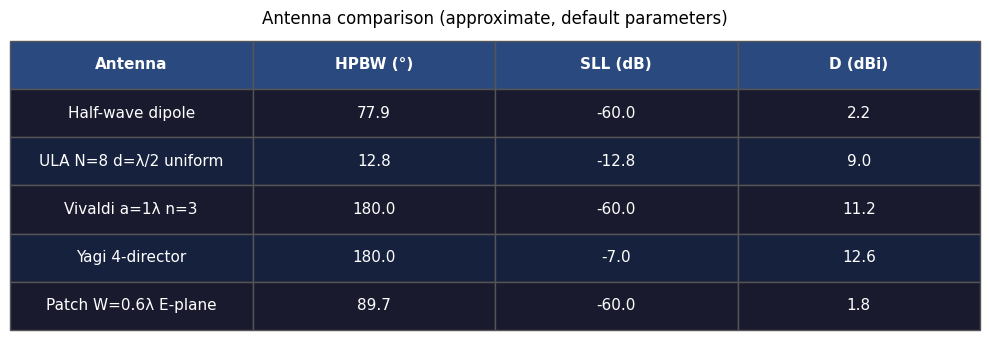

In [12]:
# --- build patterns on th_deg/th_rad grid ---
dip_pat = dipole_pattern(th_rad + np.pi/2, 0.5)

ns8 = np.arange(8)
AF8 = np.abs(np.sum(np.exp(1j*2*np.pi*0.5*ns8[:,None]*np.sin(th_rad)[None,:]), axis=0))
AF8 /= AF8.max()

viv_pat = vivaldi_pattern(th_rad + np.pi/2, 1.0, 3.0)

yag_full, _, _ = yagi_af(4, 0.25, 100)
yag_pat = np.abs(np.interp(th_deg, np.degrees(theta)-180, yag_full))
yag_pat /= yag_pat.max() + 1e-30

ee_pat, _ = patch_pats(th_rad, 0.6, 0.04)

rows_cmp = []
for name, pat in [('Half-wave dipole', dip_pat),
                   ('ULA N=8 d=λ/2 uniform', AF8),
                   ('Vivaldi a=1λ n=3', viv_pat),
                   ('Yagi 4-director', yag_pat),
                   ('Patch W=0.6λ E-plane', ee_pat)]:
    h, s, d = pat_metrics(pat)
    rows_cmp.append((name, f'{h:.1f}', f'{s:.1f}', f'{d:.1f}'))

fig_t, ax_t = plt.subplots(figsize=(10, 3.5))
ax_t.axis('off')
tbl = ax_t.table(
    cellText=rows_cmp,
    colLabels=['Antenna', 'HPBW (°)', 'SLL (dB)', 'D (dBi)'],
    cellLoc='center', loc='center', bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False);  tbl.set_fontsize(11)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#555')
    if r == 0:
        cell.set_facecolor('#2a4a7f');  cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#1a1a2e' if r%2 else '#16213e')
        cell.set_text_props(color='white')
ax_t.set_title('Antenna comparison (approximate, default parameters)', pad=12)
plt.tight_layout();  plt.show()